# DATASETS EXPLORATION (DENSE)

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1782046496.264816  191299 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782046496.365572  191299 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782046499.857772  191299 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
# file paths
BACKGROUND_FILE = "../data/datasets/dense/background_dense_dataset.h5"

SIGNAL_FILES = {
    "Ato4l":      "../data/datasets/dense/Ato4l_dense_dataset.h5",
    "hChToTauNu": "../data/datasets/dense/hChToTauNu_dense_dataset.h5",
    "hToTauTau":  "../data/datasets/dense/hToTauTau_dense_dataset.h5",
    "leptoquark": "../data/datasets/dense/leptoquark_dense_dataset.h5",
}

In [3]:
# data loader
with h5py.File(BACKGROUND_FILE, 'r') as f:
    X_train = f['X_train'][:].astype(np.float32)
    X_val   = f['X_val'][:].astype(np.float32)
    X_test  = f['X_test'][:].astype(np.float32)
print(f'{"X_train":<10}: {X_train.shape}')
print(f'{"X_val":<10}: {X_val.shape}')
print(f'{"X_test":<10}: {X_test.shape}')

signals = {}
for name, path in SIGNAL_FILES.items():
    with h5py.File(path, 'r') as f:
        key = list(f.keys())[0]
        signals[name] = f[key][:].astype(np.float32)
    print(f'{name:<10}: {signals[name].shape}')

X_train   : (8609225, 57)
X_val     : (2152307, 57)
X_test    : (2690383, 57)
Ato4l     : (55969, 57)
hChToTauNu: (760272, 57)
hToTauTau : (691283, 57)
leptoquark: (340544, 57)


In [4]:
# dataset parameters and layout
N_OBJ  = 19
N_FEAT = 3

PT_COLS  = [i * 3     for i in range(N_OBJ)]
ETA_COLS = [i * 3 + 1 for i in range(N_OBJ)]
PHI_COLS = [i * 3 + 2 for i in range(N_OBJ)]

OBJ_NAMES = (
    ["MET"] +
    [f"e{i}"  for i in range(1, 5)] +
    [f"μ{i}" for i in range(1, 5)] +
    [f"j{i}"  for i in range(1, 11)]
)

FEAT_LABELS = [r"$p_T$ (GeV)", r"$\eta$", r"$\phi$ (rad)"]
FEAT_RANGES = [(0.0, 1000.0), (-4.5, 4.5), (-3.5, 3.5)]
FEAT_LOG    = [True, False, False]

COL_NAMES = [f"{OBJ_NAMES[i]} {FEAT_LABELS[j]}"
             for i in range(N_OBJ) for j in range(N_FEAT)]

LEPTON_IDXS  = list(range(1, 9))
JET_IDXS     = list(range(9, 19))
VISIBLE_IDXS = list(range(1, 19))

OBJ_GROUPS = {
    "MET (obj 0)":     [0],
    "Electrons (1-4)": [1, 2, 3, 4],
    "Muons (5-8)":     [5, 6, 7, 8],
    "Jets (9-18)":     list(range(9, 19)),
}

In [5]:
print("Object layout:")
print(f"  {'Index':>6}  {'Name':>6}  {'PT col':>7}  {'η col':>6}  {'φ col':>6}")
for i in range(N_OBJ):
    print(f"  {i:>6}  {OBJ_NAMES[i]:>6}  {PT_COLS[i]:>7}  {ETA_COLS[i]:>6}  {PHI_COLS[i]:>6}")

Object layout:
   Index    Name   PT col   η col   φ col
       0     MET        0       1       2
       1      e1        3       4       5
       2      e2        6       7       8
       3      e3        9      10      11
       4      e4       12      13      14
       5      μ1       15      16      17
       6      μ2       18      19      20
       7      μ3       21      22      23
       8      μ4       24      25      26
       9      j1       27      28      29
      10      j2       30      31      32
      11      j3       33      34      35
      12      j4       36      37      38
      13      j5       39      40      41
      14      j6       42      43      44
      15      j7       45      46      47
      16      j8       48      49      50
      17      j9       51      52      53
      18     j10       54      55      56


In [6]:
# colors, plots and styles
GROUP_COLORS = ["blue", "red", "green", "orange"]

OBJ_COLORS = (
    ["blue"] +
    ["red"] * 4 +
    ["green"] * 4 +
    ["orange"] * 10
)

SAMPLE_COLORS = {
    "background": "black",
    "Ato4l":      "blue",
    "hChToTauNu": "red",
    "hToTauTau":  "green",
    "leptoquark": "orange",
}

plt.rcParams.update({
    "figure.dpi":           120,
    "savefig.dpi":          300,
    "font.size":            12,
    "axes.titlesize":       14,
    "axes.titlepad":        10,
    "axes.labelsize":       13,
    "axes.labelpad":        6,
    "xtick.labelsize":      11,
    "ytick.labelsize":      11,
    "legend.fontsize":      11,
    "figure.titlesize":     20,
    "axes.grid":            True,
    "grid.alpha":           0.25,
    "figure.autolayout":    True
})

## Occupancy and multiplicity distribution

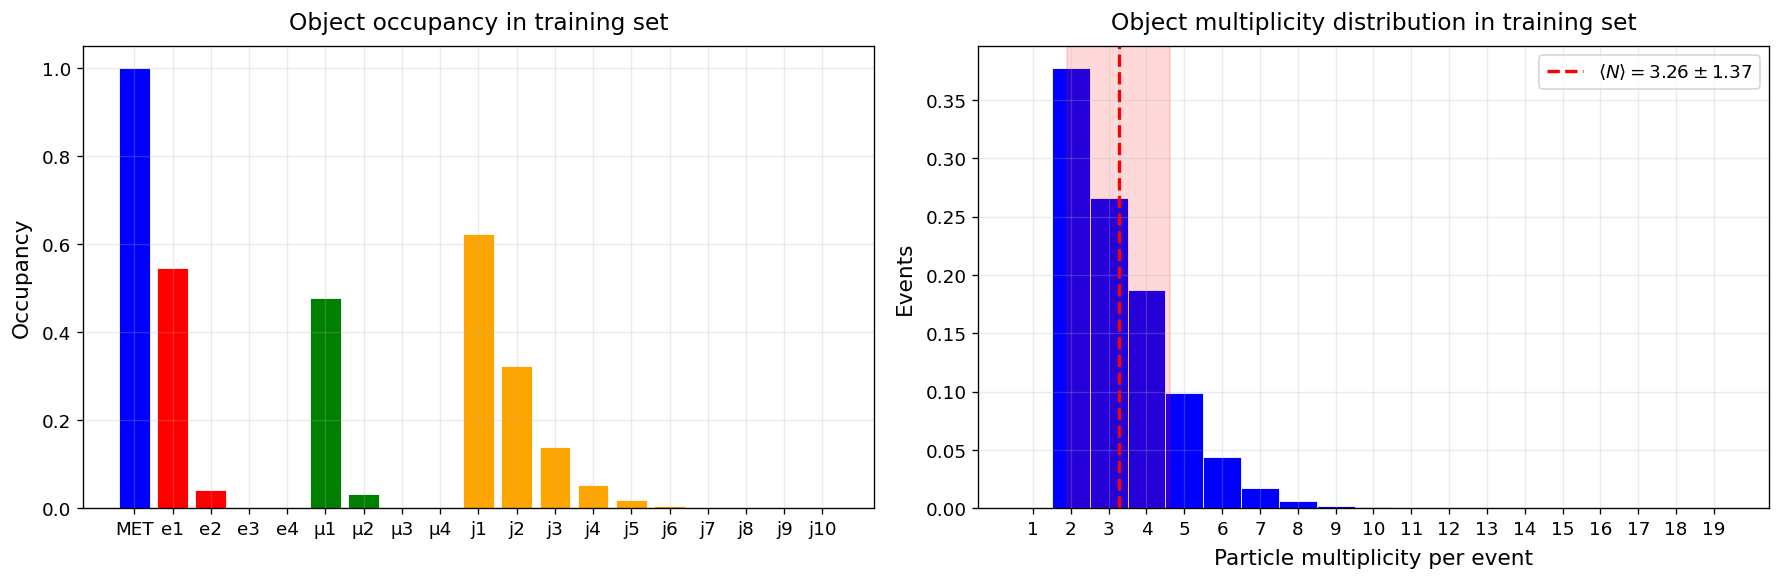

In [7]:
occupancy = (X_train[:, PT_COLS] != 0).mean(axis=0)
mult = (X_train[:, PT_COLS] != 0).sum(axis=1)
mult_mean = mult.mean()
mult_std = mult.std()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(OBJ_NAMES, occupancy, color=OBJ_COLORS, edgecolor="white", linewidth=0.5)
axes[0].set_ylabel("Occupancy")
axes[0].set_title("Object occupancy in training set")

axes[1].hist(mult, bins=np.arange(0.5, N_OBJ + 1.5), color="blue", edgecolor="white", linewidth=0.5, density=True)
axes[1].axvline(mult_mean, color="red", ls="--", lw=2, label=fr"$\langle N \rangle = {mult_mean:.2f} \pm {mult_std:.2f}$")
axes[1].axvspan(mult_mean - mult_std, mult_mean + mult_std, alpha=0.15, color="red")
axes[1].set_xlabel("Particle multiplicity per event")
axes[1].set_ylabel("Events")
axes[1].set_title("Object multiplicity distribution in training set")
axes[1].set_xticks(range(1, N_OBJ + 1))
axes[1].legend()

plt.show()

## Feature distribution by object

In [8]:
def plot_feature_hist(ax, vals, feat_j, color, lw=1.5, bins=60, density=True):
    '''
    feat_j: 0->pT, 1->eta, 2->phi
    '''
    
    v = vals[vals != 0] # remove zero-padding entries
    
    if feat_j == 0:
        v = v[v > 0]    # remove negative pT particles (not physically possible)
    
    if len(v) == 0:
        return          # check for empty arrays
    
    ax.hist(v, bins=bins, range=FEAT_RANGES[feat_j], histtype="step", linewidth=lw, color=color, density=density)
    ax.set_xlim(FEAT_RANGES[feat_j])
    
    if FEAT_LOG[feat_j]:
        ax.set_yscale("log")

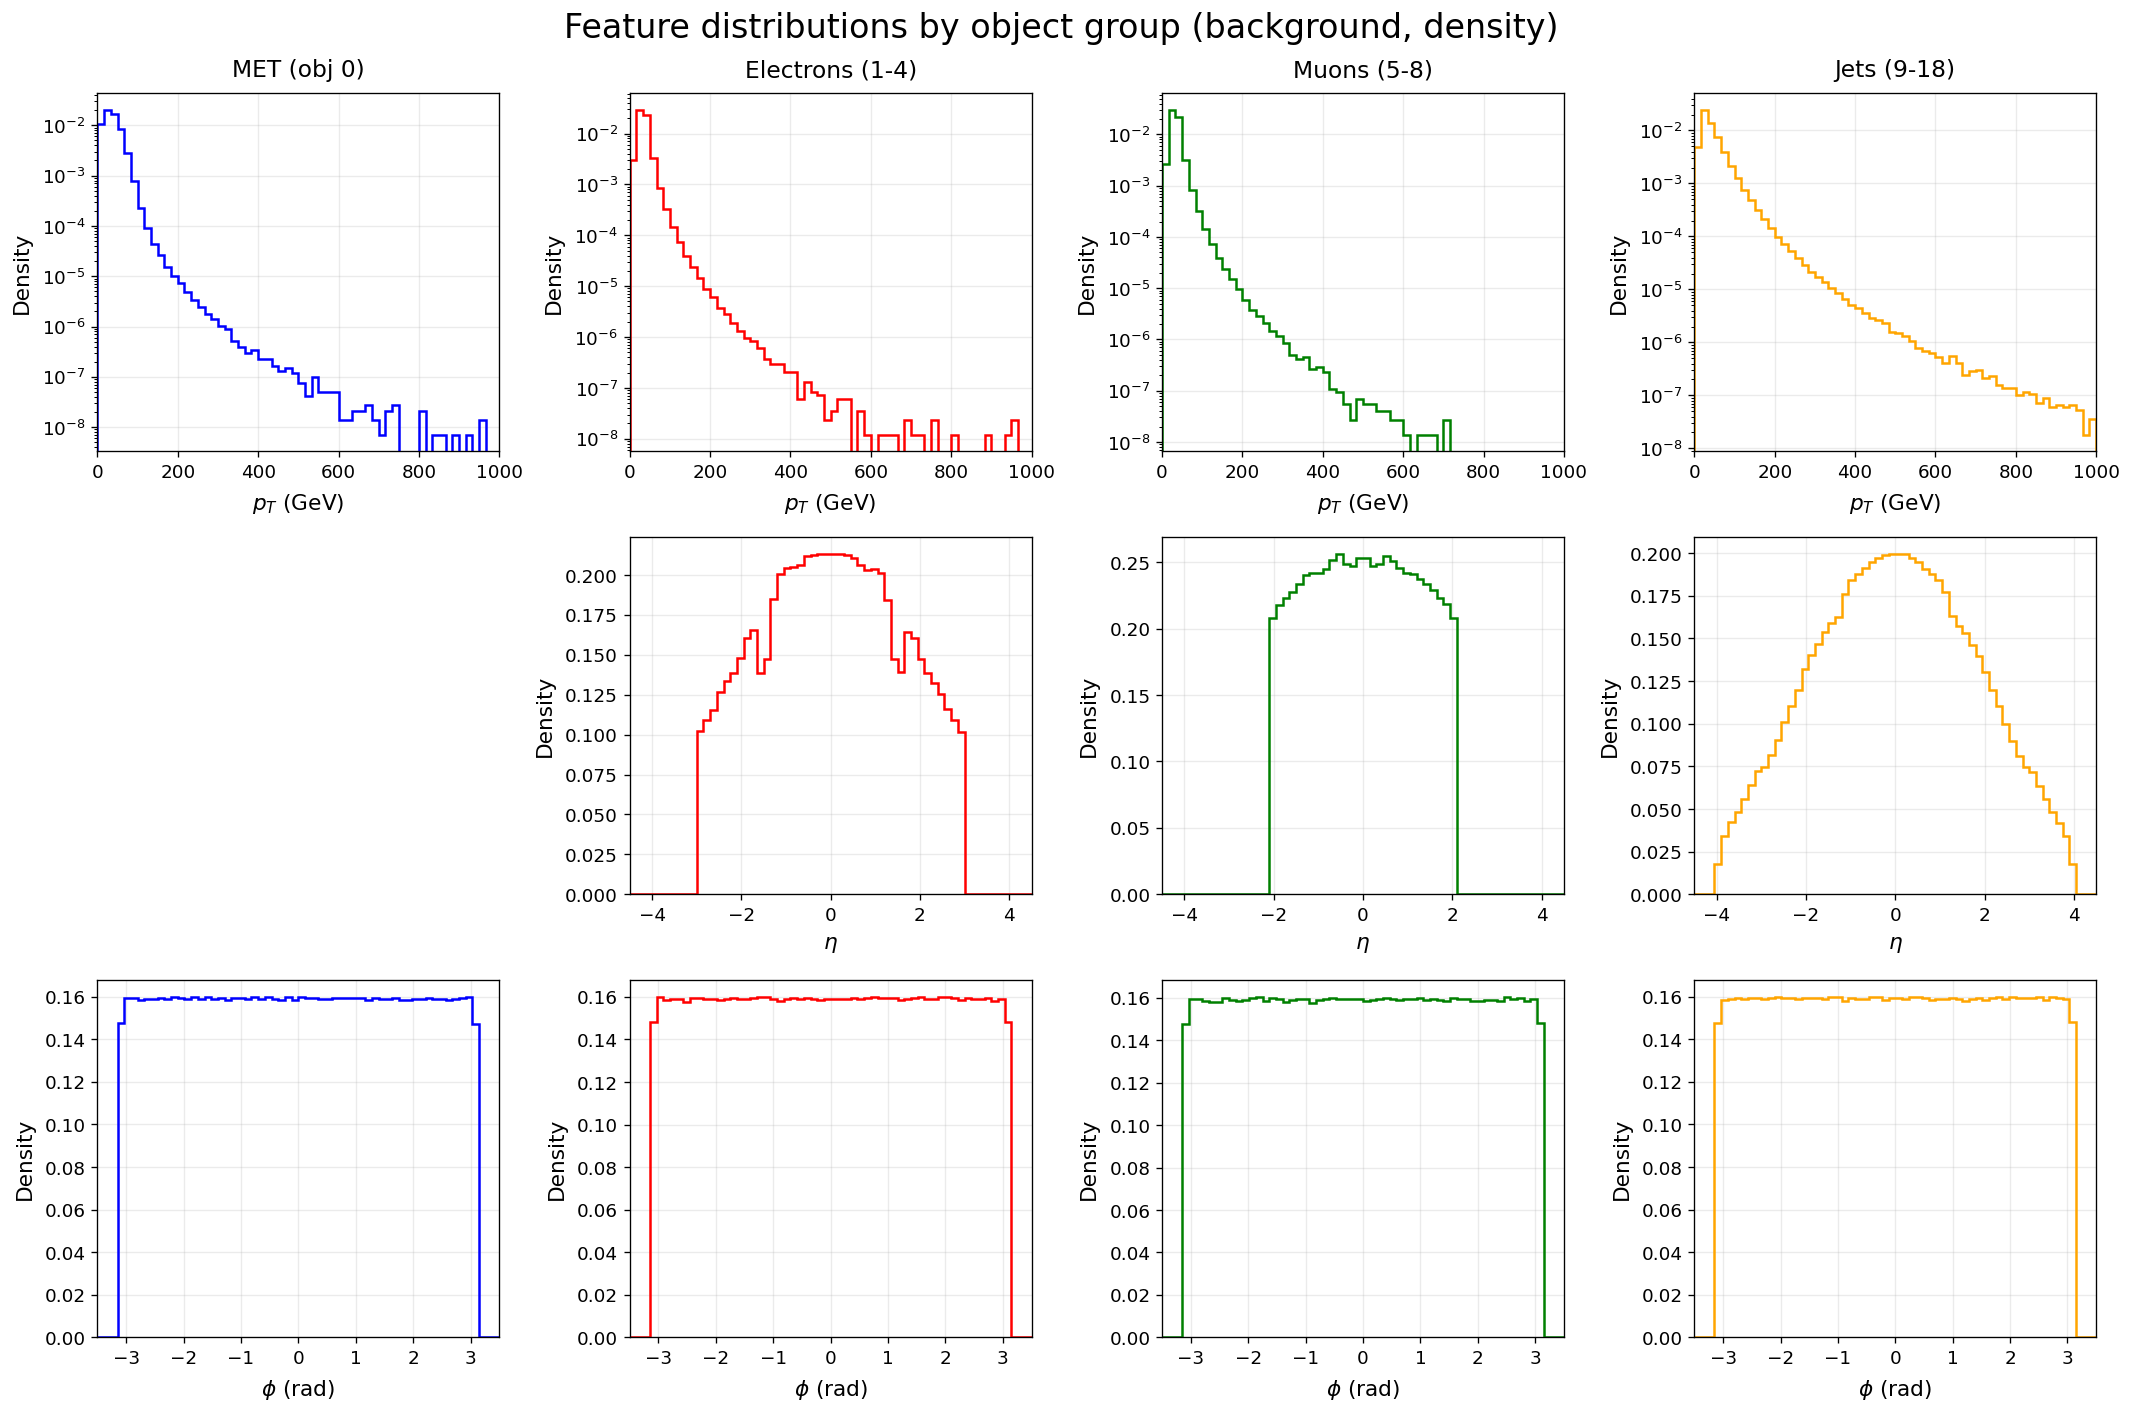

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))    # 3 variables, 4 different objects

for col, (gname, idxs) in enumerate(OBJ_GROUPS.items()):    # loop over objects
    for row, feat_j in enumerate(range(N_FEAT)):            # loop over features
        ax = axes[row, col]

        if col == 0 and row == 1:
            ax.axis("off")  # MET has no eta, plot turned off

        cols = [i * 3 + feat_j for i in idxs]
        plot_feature_hist(ax, X_train[:, cols].flatten(), feat_j, GROUP_COLORS[col])
        
        if row == 0:
            ax.set_title(gname)
        
        ax.set_ylabel("Density")
        ax.set_xlabel(FEAT_LABELS[feat_j])

plt.suptitle("Feature distributions by object group (background, density)")
plt.show()

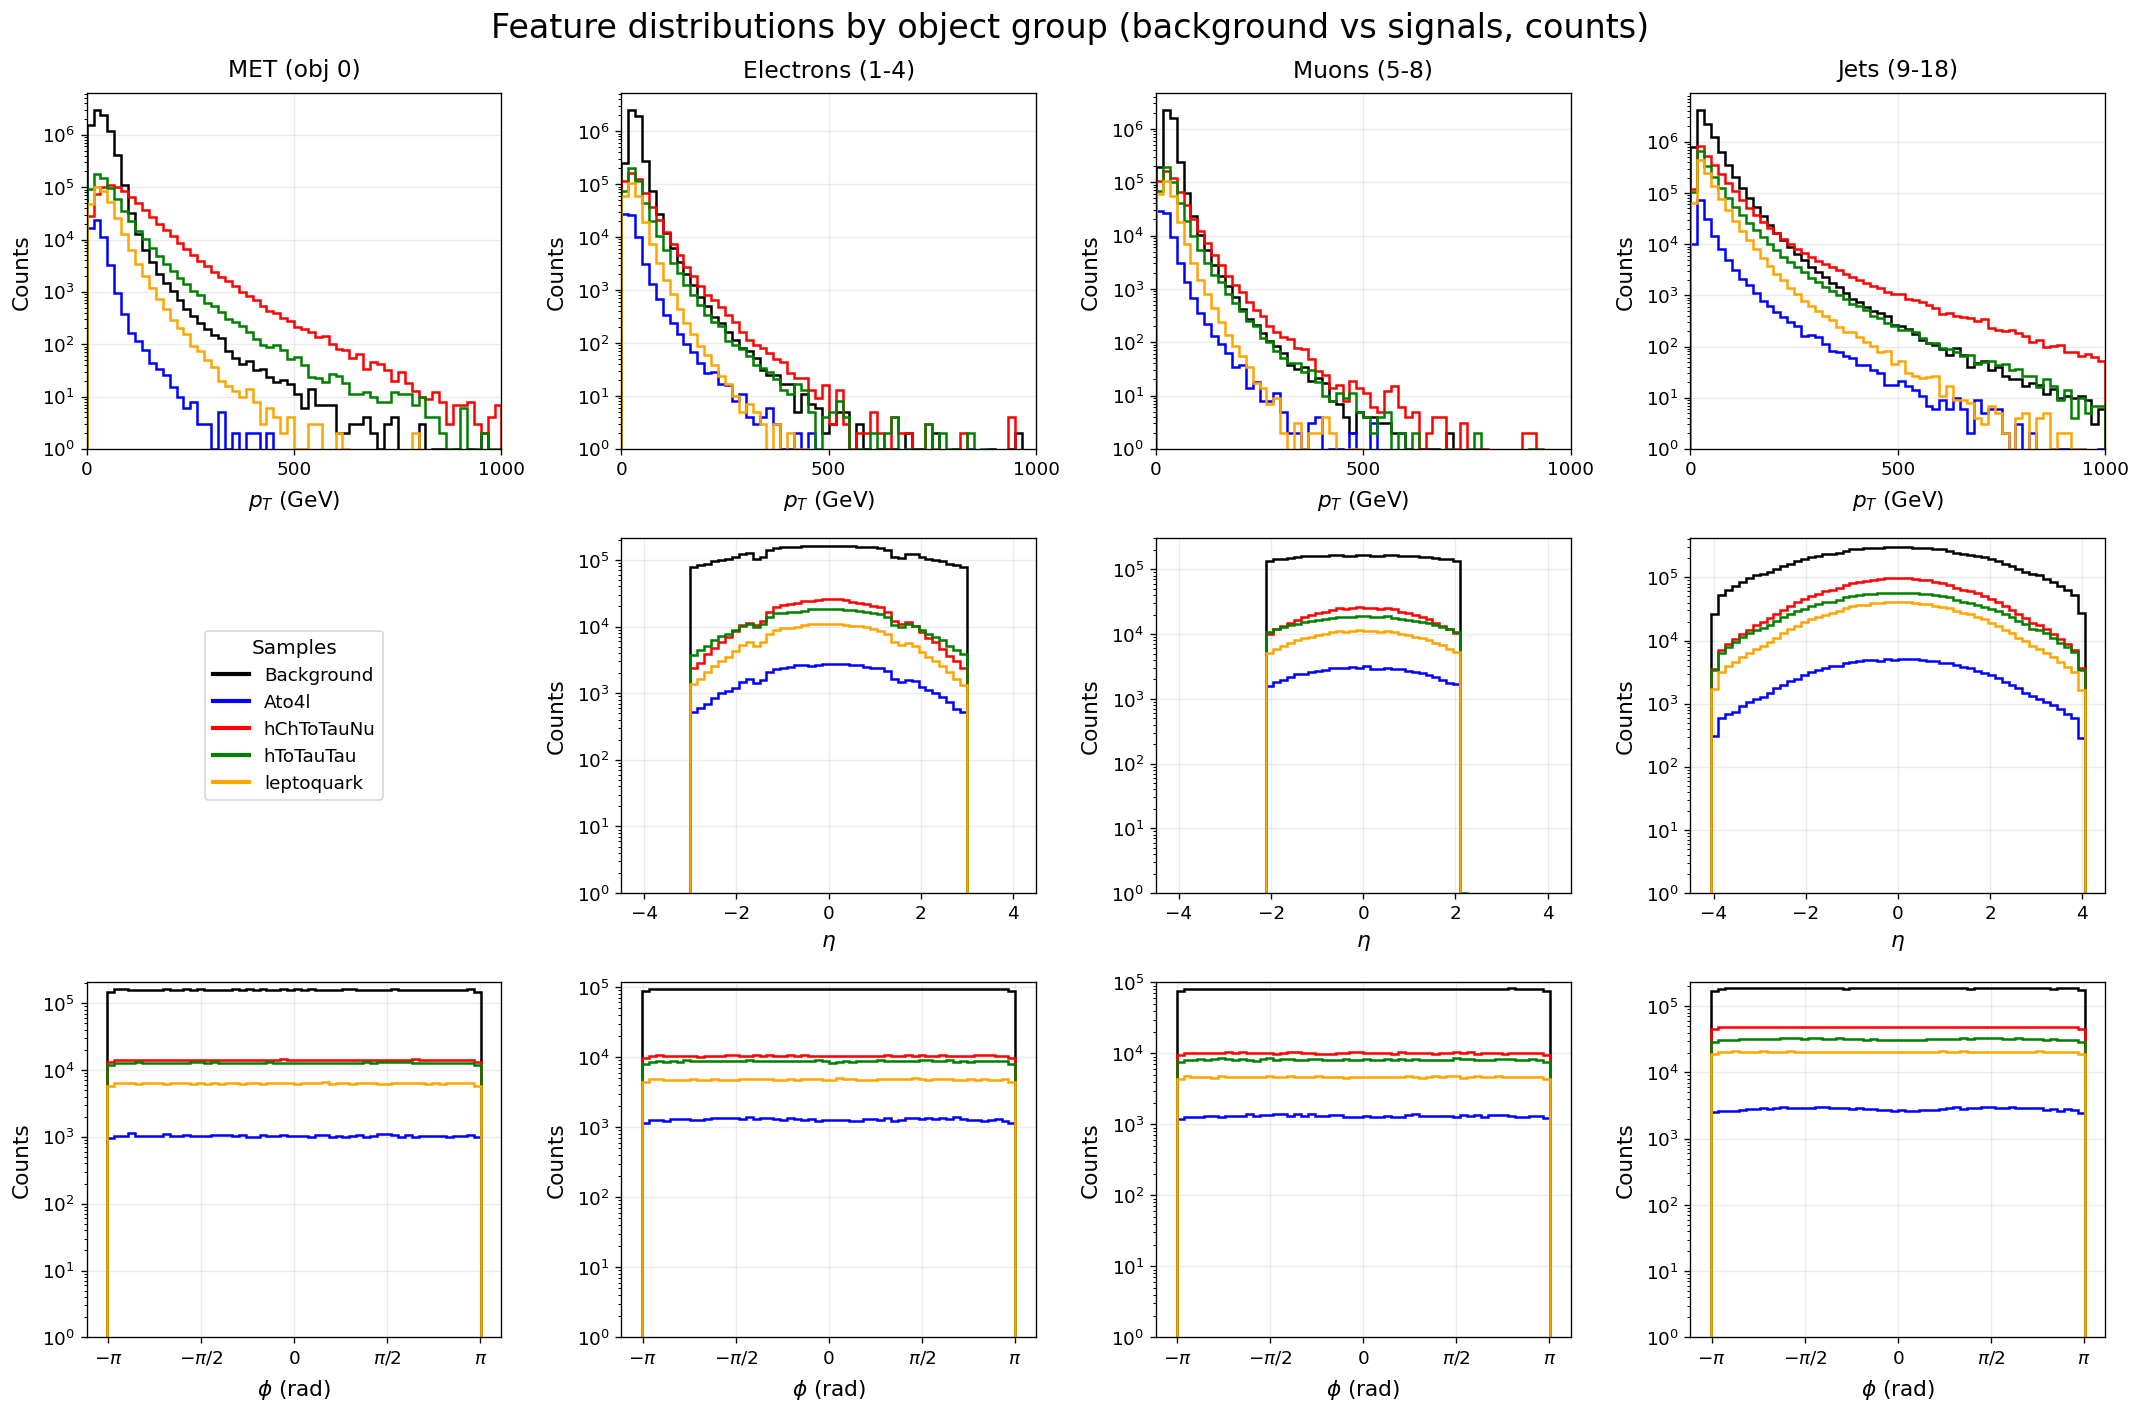

In [10]:
feature_ticks = {
    0: [0, 500, 1000],
    1: [-4, -2, 0, 2, 4],
    2: [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
}

feature_ticklabels = {
    2: [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"],
}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for col, (gname, idxs) in enumerate(OBJ_GROUPS.items()):
    for row, feat_j in enumerate(range(N_FEAT)):
        ax = axes[row, col]

        if col == 0 and row == 1:
            ax.axis("off")
            sample_items = [("Background", "background"), *[(name, name) for name in signals.keys()]]
            handles = [Line2D([0], [0], color=SAMPLE_COLORS[color_key], lw=2.5, label=label) for label, color_key in sample_items]
            ax.legend(handles=handles, loc="center", ncol=1, title="Samples", title_fontsize=12)
            continue

        cols_feat = [i * 3 + feat_j for i in idxs]

        plot_feature_hist(ax, X_train[:, cols_feat].flatten(), feat_j, SAMPLE_COLORS["background"], density=False)
        for sname, sdata in signals.items():
            plot_feature_hist(ax, sdata[:, cols_feat].flatten(), feat_j, SAMPLE_COLORS[sname], density=False)

        ax.set_yscale("log")
        ax.set_ylim(bottom=1)

        if row == 0:
            ax.set_title(gname)
        ax.set_ylabel("Counts")
        ax.set_xlabel(FEAT_LABELS[feat_j])

        ax.set_xticks(feature_ticks[feat_j])
        
        ticklabels = feature_ticklabels.get(feat_j)
        if ticklabels is not None:
            ax.set_xticklabels(ticklabels)

plt.suptitle("Feature distributions by object group (background vs signals, counts)")
plt.show()

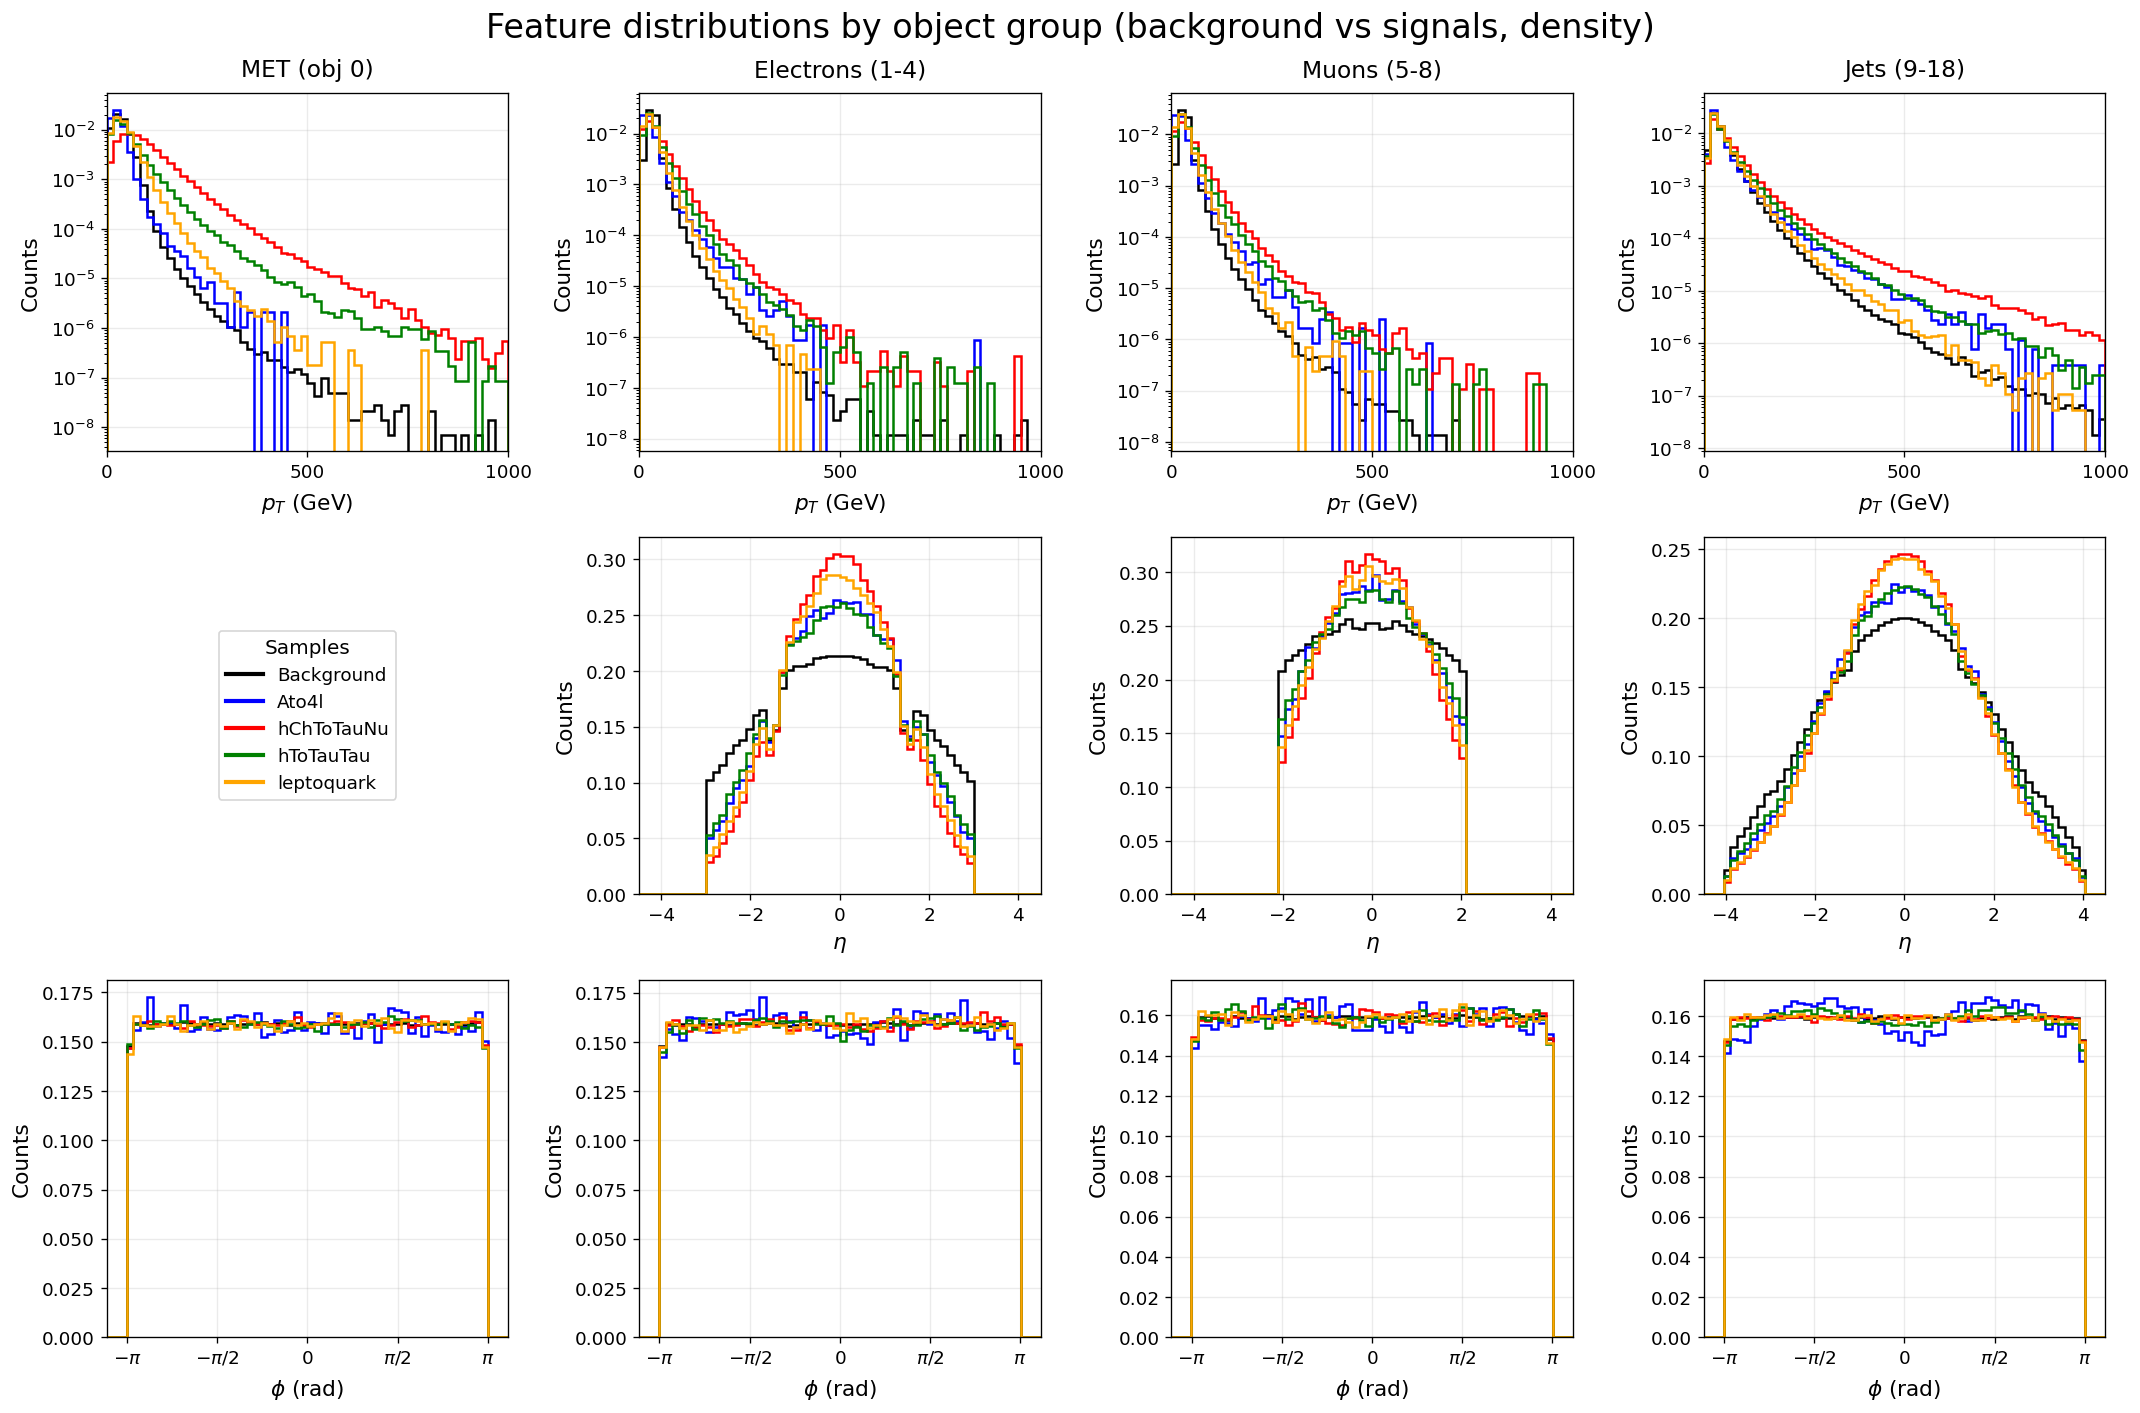

In [11]:
feature_ticks = {
    0: [0, 500, 1000],
    1: [-4, -2, 0, 2, 4],
    2: [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
}

feature_ticklabels = {
    2: [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"],
}

fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for col, (gname, idxs) in enumerate(OBJ_GROUPS.items()):
    for row, feat_j in enumerate(range(N_FEAT)):
        ax = axes[row, col]

        if col == 0 and row == 1:
            ax.axis("off")
            sample_items = [("Background", "background"), *[(name, name) for name in signals.keys()]]
            handles = [Line2D([0], [0], color=SAMPLE_COLORS[color_key], lw=2.5, label=label) for label, color_key in sample_items]
            ax.legend(handles=handles, loc="center", ncol=1, title="Samples", title_fontsize=12)
            continue

        cols_feat = [i * 3 + feat_j for i in idxs]

        plot_feature_hist(ax, X_train[:, cols_feat].flatten(), feat_j, SAMPLE_COLORS["background"], density=True)
        for sname, sdata in signals.items():
            plot_feature_hist(ax, sdata[:, cols_feat].flatten(), feat_j, SAMPLE_COLORS[sname], density=True)

        if row == 0:
            ax.set_title(gname)
        ax.set_ylabel("Counts")
        ax.set_xlabel(FEAT_LABELS[feat_j])

        ax.set_xticks(feature_ticks[feat_j])
        
        ticklabels = feature_ticklabels.get(feat_j)
        if ticklabels is not None:
            ax.set_xticklabels(ticklabels)

plt.suptitle("Feature distributions by object group (background vs signals, density)")
plt.show()

## Physics observables

In [12]:
def reshape_particles(X):
    # Dense layout: [pt, eta, phi] repeated for each object.
    return X.reshape(X.shape[0], N_OBJ, N_FEAT)


def topk_objects_by_pt(X, object_indices, k):
    """
    Return top-k objects by pt among object_indices and a validity mask.
    Padding entries (pt <= 0) are moved to the end.
    """
    block = reshape_particles(X)[:, object_indices, :]
    valid = block[..., 0] > 0
    order = np.argsort(np.where(valid, -block[..., 0], np.inf), axis=1)
    top = np.take_along_axis(block, order[:, :k, None], axis=1)
    top_mask = np.take_along_axis(valid, order[:, :k], axis=1)
    return top, top_mask


def massless_four_vectors(block):
    pt, eta, phi = block[..., 0], block[..., 1], block[..., 2]
    e = pt * np.cosh(eta)
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    return np.stack([e, px, py, pz], axis=-1)


def invariant_mass(vectors):
    total = vectors.sum(axis=-2)
    mass2 = total[..., 0] ** 2 - np.sum(total[..., 1:] ** 2, axis=-1)
    return np.sqrt(np.clip(mass2, 0.0, None))


def pair_mass(X, object_indices):
    top, mask = topk_objects_by_pt(X, object_indices, k=2)
    valid = mask[:, 0] & mask[:, 1]
    m = invariant_mass(massless_four_vectors(top))
    return m[valid & np.isfinite(m)]


def four_object_mass(X, object_indices):
    top, mask = topk_objects_by_pt(X, object_indices, k=4)
    valid = mask.all(axis=1)
    m = invariant_mass(massless_four_vectors(top))
    return m[valid & np.isfinite(m)]


def transverse_mass(X, lepton_indices, met_index=0):
    lepton, lep_mask = topk_objects_by_pt(X, lepton_indices, k=1)
    met = reshape_particles(X)[:, met_index, :]
    valid = lep_mask[:, 0] & (met[:, 0] > 0)

    dphi = np.arctan2(
        np.sin(lepton[:, 0, 2] - met[:, 2]),
        np.cos(lepton[:, 0, 2] - met[:, 2]),
    )
    mt = np.sqrt(np.clip(2.0 * lepton[:, 0, 0] * met[:, 0] * (1.0 - np.cos(dphi)), 0.0, None))
    return mt[valid & np.isfinite(mt)]

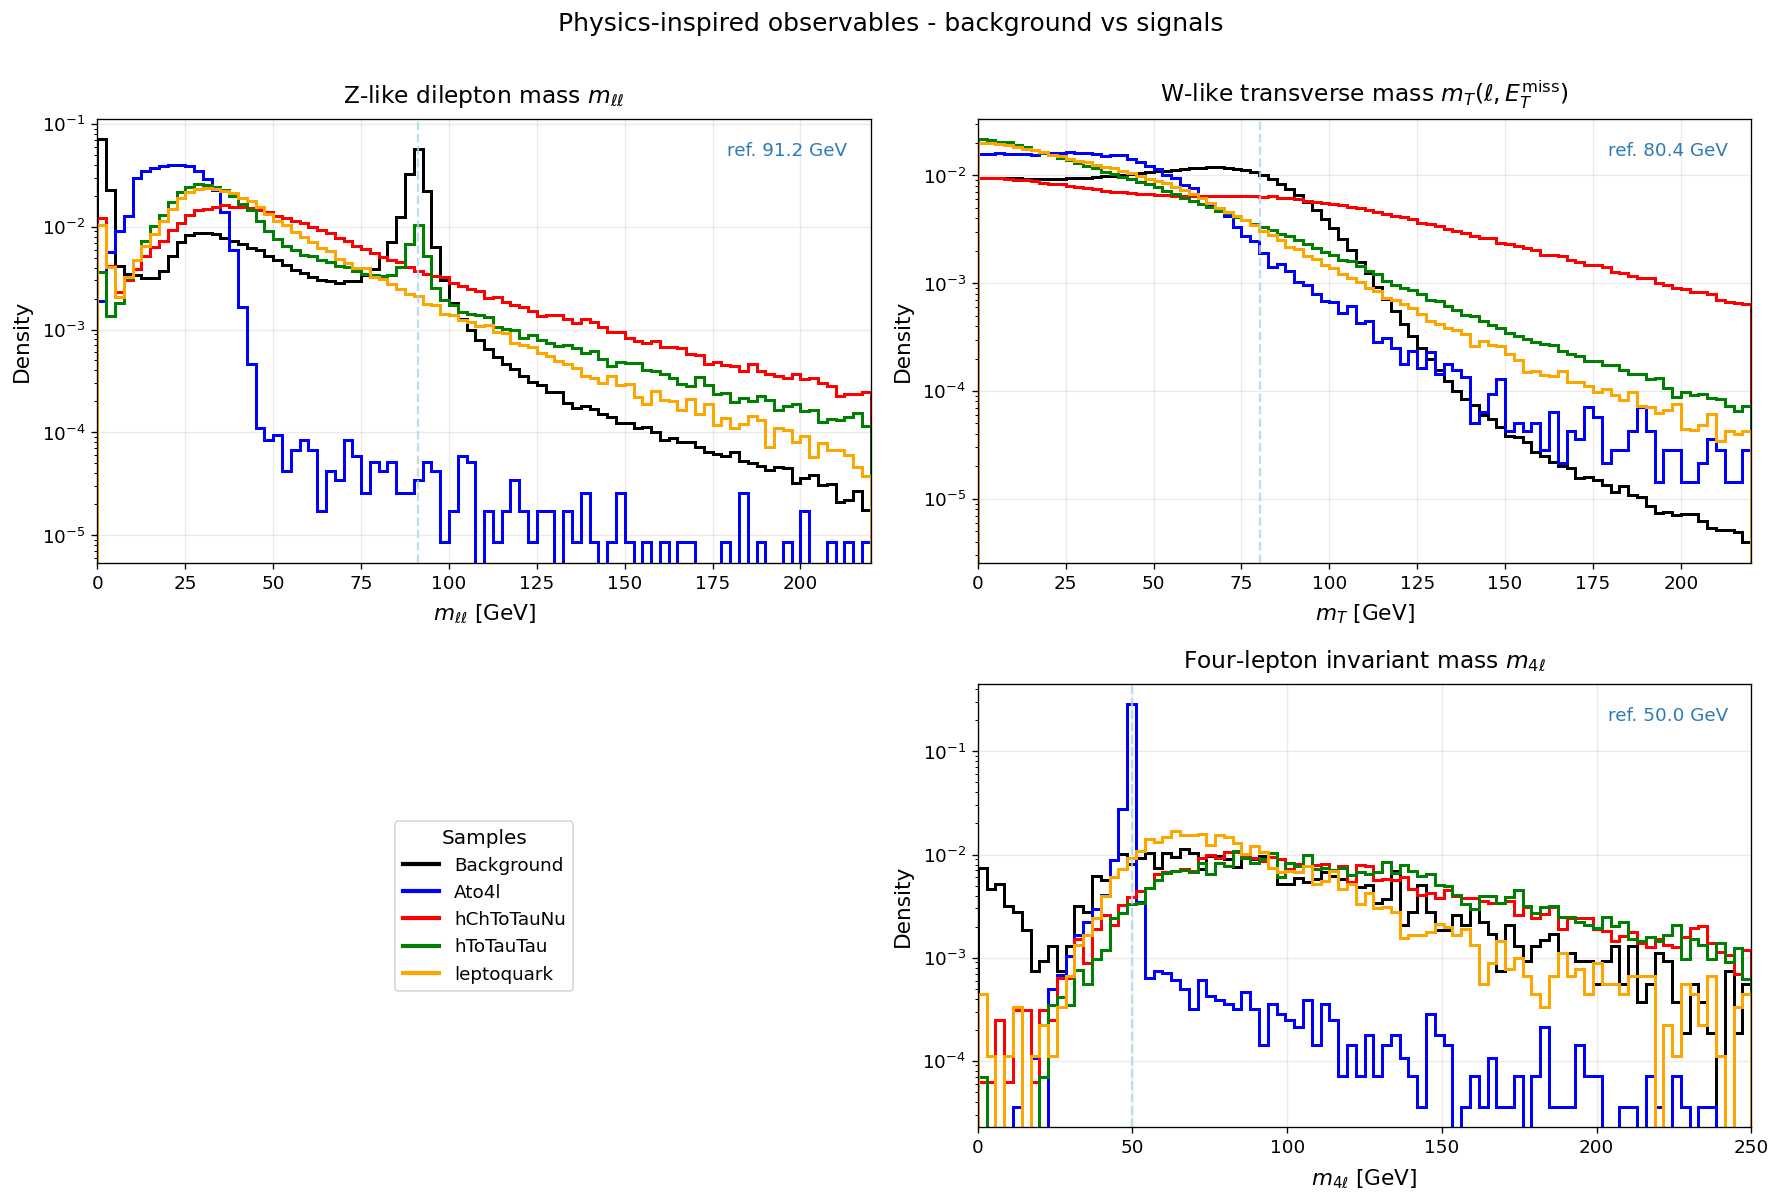

In [13]:
observable_specs = [
    {
        "title": r"Z-like dilepton mass $m_{\ell\ell}$",
        "extractor": lambda X: pair_mass(X, LEPTON_IDXS),
        "xlabel": r"$m_{\ell\ell}$ [GeV]",
        "xlim": (0.0, 220.0),
        "bins": 88,
        "reference": 91.2,
    },
    {
        "title": r"W-like transverse mass $m_T(\ell, E_T^{\rm miss})$",
        "extractor": lambda X: transverse_mass(X, LEPTON_IDXS),
        "xlabel": r"$m_T$ [GeV]",
        "xlim": (0.0, 220.0),
        "bins": 88,
        "reference": 80.4,
    },
    {
        "title": r"Four-lepton invariant mass $m_{4\ell}$",
        "extractor": lambda X: four_object_mass(X, LEPTON_IDXS),
        "xlabel": r"$m_{4\ell}$ [GeV]",
        "xlim": (0.0, 250.0),
        "bins": 88,
        "reference": 50.0,
    },
]

sample_datasets = {"Background": X_train, **signals}

# Precompute each observable once per sample: cleaner plotting loop and faster reruns.
observable_values = {
    spec["title"]: {
        sample_name: spec["extractor"](dataset)
        for sample_name, dataset in sample_datasets.items()
    }
    for spec in observable_specs
}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
panel_specs = [observable_specs[0], observable_specs[1], None, observable_specs[2]]

for ax, spec in zip(axes.flat, panel_specs):
    if spec is None:
        ax.axis("off")
        sample_items = [("Background", "background"), *[(name, name) for name in signals.keys()]]
        handles = [
            Line2D([0], [0], color=SAMPLE_COLORS[color_key], lw=2.5, label=label)
            for label, color_key in sample_items
        ]
        ax.legend(handles=handles, loc="center", ncol=1, fontsize=11, title="Samples", title_fontsize=12)
        continue

    for sample_name, values in observable_values[spec["title"]].items():
        ax.hist(
            values,
            bins=spec["bins"],
            range=spec["xlim"],
            density=True,
            histtype="step",
            linewidth=1.8,
            color=SAMPLE_COLORS[sample_name if sample_name != "Background" else "background"],
            label=sample_name,
        )

    ax.axvline(spec["reference"], color="lightblue", ls="--", lw=1.4, alpha=0.8)
    ax.text(
        0.97,
        0.95,
        f"ref. {spec['reference']:.1f} GeV",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        color="#2c7bb6",
    )
    ax.set_title(spec["title"])
    ax.set_xlabel(spec["xlabel"])
    ax.set_ylabel("Density")
    ax.set_xlim(spec["xlim"])
    ax.set_yscale("log")

plt.suptitle("Physics-inspired observables - background vs signals", fontsize=15, y=1.0)
plt.show()